# TechNova GmbH — AWS FinOps Analysis
### Client: TechNova GmbH | Analyst: Cortex Reply FinOps Team | Period: Jan–Mar 2024

---

## Project Background

> **From:** Marcus Weber, CTO — TechNova GmbH
> **To:** Cortex Reply FinOps Team
> **Subject:** AWS Cost Spike — Need Urgent Analysis
>
> Our AWS bill jumped from €42,000/month to €71,000/month over the last 3 months and nobody on our side can explain why. We have 3 engineering teams (Backend, Data Platform, DevOps) all sharing one AWS account.
>
> We've never done any FinOps work before. No real tagging strategy, no reserved instances, no cost reviews. Just spinning up whatever we need.
>
> We need you to tell us:
> 1. Where is our money going?
> 2. Which team is spending what?
> 3. Where are we wasting money?
> 4. What should we do about it?
>
> — Marcus Weber, CTO

---

## Objectives
1. Clean and merge 3 raw AWS datasets
2. Identify top cost drivers by service and team
3. Find waste — untagged spend, idle resources, uncontrolled storage
4. Quantify savings potential in EUR
5. Deliver findings and recommendations

---

## Datasets

| File | Description | Rows |
|------|-------------|------|
| `aws_billing.csv` | AWS Cost & Usage data — service, cost, tags, region | 126 |
| `ec2_usage_metrics.csv` | CPU & memory utilization per EC2 instance | 54 |
| `resource_inventory.csv` | Master list of all resources with owner & team metadata | 42 |


## 1. Setup
### 1.1 Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### 1.2 Load Datasets

In [33]:
billing   = pd.read_csv('aws_billing.csv')
usage     = pd.read_csv('ec2_usage_metrics.csv')
inventory = pd.read_csv('resource_inventory.csv')
print('done')

done


## 2. Data Exploration

Before cleaning or merging, we explore each dataset to understand its structure, column types, and missing values.

### 2.1 Billing Dataset

In [34]:
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   line_item_id      126 non-null    object 
 1   billing_period    126 non-null    object 
 2   usage_start_date  126 non-null    object 
 3   usage_end_date    126 non-null    object 
 4   service           126 non-null    object 
 5   resource_id       126 non-null    object 
 6   usage_type        126 non-null    object 
 7   usage_amount      126 non-null    float64
 8   usage_unit        126 non-null    object 
 9   unblended_cost    126 non-null    float64
 10  currency          126 non-null    object 
 11  region            126 non-null    object 
 12  pricing_term      126 non-null    object 
 13  tag_team          84 non-null     object 
 14  tag_environment   76 non-null     object 
 15  tag_project       76 non-null     object 
dtypes: float64(2), object(14)
memory usage: 15.9

In [35]:
billing.head(3)

,line_item_id,billing_period,usage_start_date,usage_end_date,service,resource_id,usage_type,usage_amount,usage_unit,unblended_cost,currency,region,pricing_term,tag_team,tag_environment,tag_project
0,LI-1000,2024-01,2024-01-01,2024-01-31,Amazon EC2,i-00bc1b7,BoxUsage:m5.large,628.6326,Hrs,60.3487,USD,eu-central-1,OnDemand,backend,prod,api-core
1,LI-1001,2024-01,2024-01-01,2024-01-31,Amazon EC2,i-0034ea3,BoxUsage:c5.4xlarge,631.7434,Hrs,429.5855,USD,eu-central-1,OnDemand,backend,production,api-core
2,LI-1002,2024-01,2024-01-01,2024-01-31,Amazon EC2,i-001ed11,BoxUsage:m5.2xlarge,700.5321,Hrs,269.0043,USD,eu-central-1,OnDemand,backend,NaN,NaN


### 2.2 EC2 Usage Metrics

In [36]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   billing_period              54 non-null     object 
 1   resource_id                 54 non-null     object 
 2   instance_type               54 non-null     object 
 3   team                        54 non-null     object 
 4   avg_cpu_utilization_pct     54 non-null     float64
 5   max_cpu_utilization_pct     54 non-null     float64
 6   avg_memory_utilization_pct  54 non-null     float64
 7   running_hours_total         54 non-null     float64
 8   running_on_weekends         54 non-null     bool   
 9   region                      54 non-null     object 
dtypes: bool(1), float64(4), object(5)
memory usage: 4.0+ KB


### 2.3 Resource Inventory

In [37]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   resource_id    42 non-null     object
 1   service        42 non-null     object
 2   resource_name  42 non-null     object
 3   region         42 non-null     object
 4   team           24 non-null     object
 5   owner_email    19 non-null     object
 6   cost_center    19 non-null     object
 7   environment    35 non-null     object
 8   created_date   42 non-null     object
 9   is_active      42 non-null     bool  
dtypes: bool(1), object(9)
memory usage: 3.1+ KB


In [38]:
inventory.head(3)

,resource_id,service,resource_name,region,team,owner_email,cost_center,environment,created_date,is_active
0,i-00bc1b7,Amazon EC2,amazon_ec2_0bc1b7,eu-central-1,backend,backend-lead@technova.de,CC-1001,production,2023-02-18,True
1,i-0034ea3,Amazon EC2,amazon_ec2_034ea3,eu-central-1,backend,backend-lead@technova.de,CC-1001,development,2023-02-28,True
2,i-001ed11,Amazon EC2,amazon_ec2_01ed11,eu-central-1,backend,NaN,NaN,NaN,2023-01-06,False


### 2.4 Missing Values Summary

In [39]:
print("=== MISSING VALUES ===")
print("\nbilling:")
print(billing.isnull().sum())
print("\nusage:")
print(usage.isnull().sum())
print("\ninventory:")
print(inventory.isnull().sum())

=== MISSING VALUES ===

billing:
line_item_id         0
billing_period       0
usage_start_date     0
usage_end_date       0
service              0
resource_id          0
usage_type           0
usage_amount         0
usage_unit           0
unblended_cost       0
currency             0
region               0
pricing_term         0
tag_team            42
tag_environment     50
tag_project         50
dtype: int64

usage:
billing_period                0
resource_id                   0
instance_type                 0
team                          0
avg_cpu_utilization_pct       0
max_cpu_utilization_pct       0
avg_memory_utilization_pct    0
running_hours_total           0
running_on_weekends           0
region                        0
dtype: int64

inventory:
resource_id       0
service           0
resource_name     0
region            0
team             18
owner_email      23
cost_center      23
environment       7
created_date      0
is_active         0
dtype: int64


## 3. Data Cleaning

Issues identified during exploration:
- Date columns stored as strings — need to convert to `datetime`
- Environment values inconsistent (`dev` vs `development`, `prod` vs `production`) — normalize
- Missing tag values — fill with `'untagged'` to track unallocated cost
- Missing inventory fields — fill with placeholder values
- All costs in USD — convert to EUR (rate: 1 USD = 0.92 EUR)

### 3.1 Fix Date Columns & Normalize Environment Values

In [40]:
billing['usage_start_date'] = pd.to_datetime(billing['usage_start_date'])
billing['usage_end_date']   = pd.to_datetime(billing['usage_end_date'])
inventory['created_date']   = pd.to_datetime(inventory['created_date'])

env_map = {
    'dev':'development','development':'development',
    'prod':'production','production':'production','staging':'staging'
}
billing['tag_environment']  = billing['tag_environment'].map(env_map)
inventory['environment']    = inventory['environment'].map(env_map)

### 3.2 Fill Missing Tag Values

In [41]:
billing['tag_team']        = billing['tag_team'].fillna('untagged')
billing['tag_environment'] = billing['tag_environment'].fillna('untagged')
billing['tag_project']     = billing['tag_project'].fillna('untagged')

### 3.3 Fill Missing Inventory Fields

In [42]:
inventory['team']        = inventory['team'].fillna('untagged')
inventory['owner_email'] = inventory['owner_email'].fillna('no-owner')
inventory['cost_center'] = inventory['cost_center'].fillna('unassigned')
inventory['environment'] = inventory['environment'].fillna('unknown')

### 3.4 Convert USD to EUR

In [43]:
billing['cost_eur'] = (billing['unblended_cost'] * 0.92).round(2)

## 4. Data Merging

We merge all 3 datasets into a single enriched dataframe `df` using `billing` as the base table.

**Merge 1 — billing + inventory**
- Join key: `resource_id`
- Type: LEFT JOIN — adds owner metadata from inventory
- Adds: `team`, `owner_email`, `cost_center`, `environment`

**Merge 2 — result + usage**
- Join key: `resource_id` + `billing_period`
- Type: LEFT JOIN — adds CPU/memory for EC2 rows only
- Adds: `avg_cpu_utilization_pct`, `max_cpu_utilization_pct`, `avg_memory_utilization_pct`, `running_hours_total`, `running_on_weekends`
- Note: CPU columns will be NaN for non-EC2 services — expected

**Expected result:** 126 rows, 26 columns

In [44]:
df = billing.merge(
    inventory[['resource_id','team','owner_email','cost_center','environment']],
    on='resource_id', how='left')

df = df.merge(
    usage[['resource_id','billing_period','avg_cpu_utilization_pct',
           'max_cpu_utilization_pct','avg_memory_utilization_pct',
           'running_hours_total','running_on_weekends']],
    on=['resource_id','billing_period'], how='left')

print(df.shape)

(126, 26)


## 5. Analysis

### 5.0 Re-create All Analysis Dataframes

All analysis dataframes are defined here in one place to avoid `NameError` if the kernel is restarted.

In [45]:
monthly    = df.groupby('billing_period')['cost_eur'].sum().round(2).reset_index()
monthly.columns = ['month','total_cost_eur']

by_service = df.groupby('service')['cost_eur'].sum().sort_values(ascending=True)

by_team    = df.groupby(['billing_period','tag_team'])['cost_eur'].sum().round(2).reset_index()
by_team    = by_team.sort_values(['billing_period','cost_eur'], ascending=[True,False])

untagged   = df[df['tag_team']=='untagged'].groupby('service')['cost_eur'].sum().round(2).reset_index()
untagged   = untagged.sort_values('cost_eur', ascending=False)
untagged['pct_of_total'] = (untagged['cost_eur'] / df['cost_eur'].sum() * 100).round(1)

idle       = df[(df['service']=='Amazon EC2') &
                (df['avg_cpu_utilization_pct'] < 10)].dropna(subset=['avg_cpu_utilization_pct'])
idle_summary = idle.groupby('resource_id').agg(
    avg_cpu=('avg_cpu_utilization_pct','mean'),
    total_cost=('cost_eur','sum')).reset_index()

s3         = df[df['service']=='Amazon S3'].groupby(
    ['billing_period','resource_id'])['cost_eur'].sum().round(2).reset_index()
raw_logs   = s3[s3['resource_id']=='technova-raw-logs']

print("All dataframes ready")

All dataframes ready


### 5.1 Monthly Cost Trend

**Question:** Is the bill growing, and in which month did it spike?

In [46]:
print(monthly)

     month  total_cost_eur
0  2024-01         6144.84
1  2024-02         9250.83
2  2024-03         8549.74


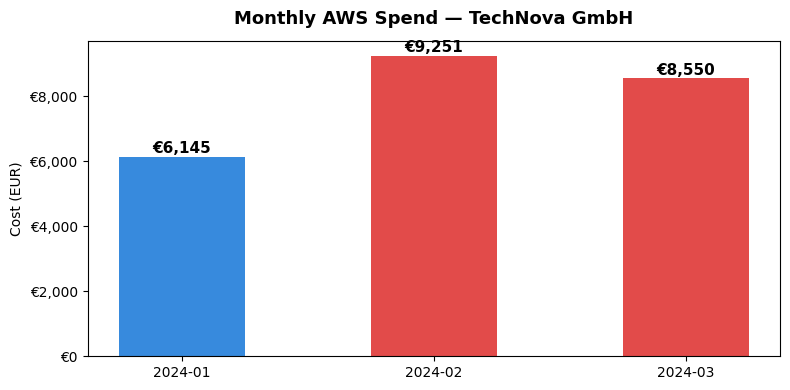

In [47]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(monthly['month'], monthly['total_cost_eur'], color=['#378ADD','#E24B4A','#E24B4A'], width=0.5)
ax.set_title('Monthly AWS Spend — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,row in monthly.iterrows():
    ax.text(i, row['total_cost_eur']+120, f"€{row['total_cost_eur']:,.0f}", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart1_monthly_cost.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Cost by Service

**Question:** Which AWS service is driving the most spend?

In [48]:
by_service_total = df.groupby('service')['cost_eur'].sum().sort_values(ascending=False)
print(by_service_total.round(2))

service
Amazon EC2            10257.97
Amazon S3              7053.50
Amazon RDS             3770.98
Amazon ElastiCache     1176.63
AWS Data Transfer       932.56
Amazon EKS              496.94
Amazon CloudFront       253.15
AWS Lambda                3.68
Name: cost_eur, dtype: float64


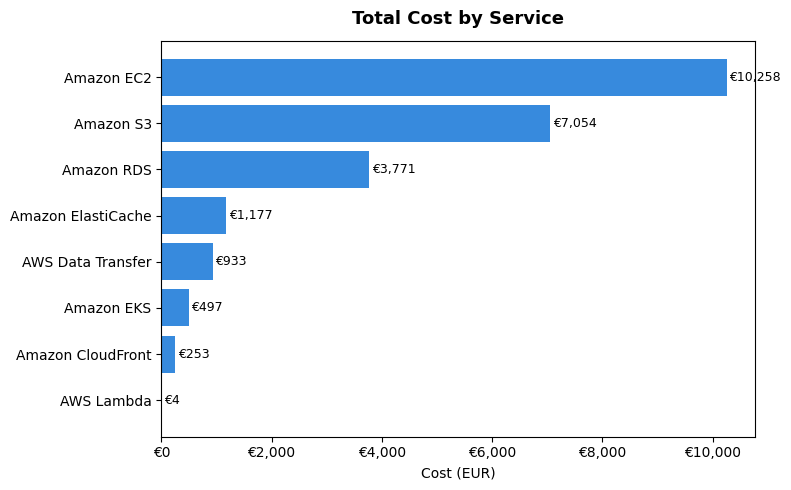

In [49]:
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(by_service.index, by_service.values, color='#378ADD')
ax.set_title('Total Cost by Service', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,val in enumerate(by_service.values):
    ax.text(val+50, i, f'€{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart2_cost_by_service.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Cost by Team

**Question:** Which team is spending what — and who owns the spike?

In [50]:
print(by_team.to_string(index=False))

billing_period      tag_team  cost_eur
       2024-01      untagged   3420.15
       2024-01       backend   1711.01
       2024-01 data-platform    759.41
       2024-01        devops    254.27
       2024-02 data-platform   2998.70
       2024-02      untagged   2687.60
       2024-02       backend   2106.80
       2024-02        devops   1457.73
       2024-03      untagged   3503.33
       2024-03 data-platform   2573.34
       2024-03       backend   1461.11
       2024-03        devops   1011.96


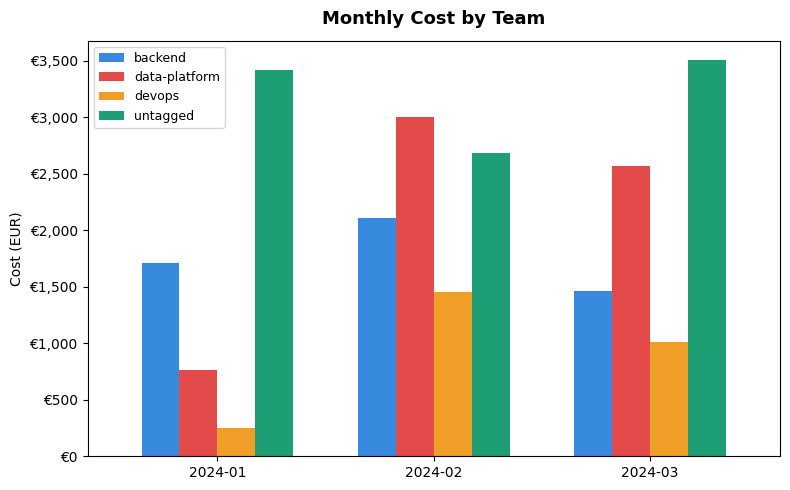

In [51]:
fig, ax = plt.subplots(figsize=(8,5))
team_pivot = by_team.pivot(index='billing_period', columns='tag_team', values='cost_eur').fillna(0)
team_pivot.plot(kind='bar', ax=ax, width=0.7, color=['#378ADD','#E24B4A','#EF9F27','#1D9E75'])
ax.set_title('Monthly Cost by Team', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('charts/chart3_cost_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Untagged Spend

**Question:** How much spend has no team owner — and which services are untagged?

Untagged spend = rows where `tag_team` is `'untagged'`. Finance cannot do chargeback on this amount.

In [52]:
print(untagged.to_string(index=False))
print(f"\nTotal untagged cost: €{untagged['cost_eur'].sum():.2f}")
print(f"% of total spend:    {untagged['pct_of_total'].sum():.1f}%")

           service  cost_eur  pct_of_total
         Amazon S3   4985.28          20.8
        Amazon EC2   2315.32           9.7
        Amazon RDS   1012.13           4.2
Amazon ElastiCache    647.25           2.7
 AWS Data Transfer    427.94           1.8
        Amazon EKS    180.02           0.8
 Amazon CloudFront     41.87           0.2
        AWS Lambda      1.27           0.0

Total untagged cost: €9611.08
% of total spend:    40.2%


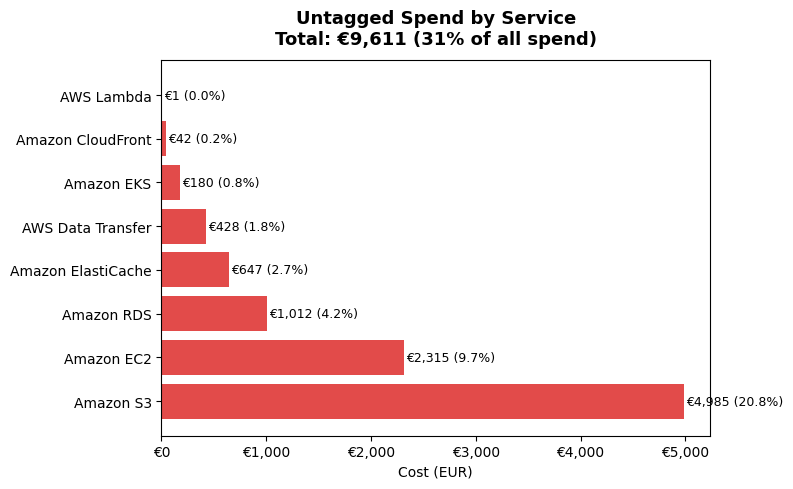

In [53]:
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(untagged['service'], untagged['cost_eur'], color='#E24B4A')
ax.set_title(f"Untagged Spend by Service\nTotal: €{untagged['cost_eur'].sum():,.0f} (31% of all spend)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,(val,pct) in enumerate(zip(untagged['cost_eur'], untagged['pct_of_total'])):
    ax.text(val+20, i, f'€{val:,.0f} ({pct}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.5 Idle EC2 Instances

**Question:** Are any EC2 instances running with very low CPU — wasting money?

Idle threshold: avg CPU utilization < 10%.

In [54]:
print(idle[['resource_id','tag_team','avg_cpu_utilization_pct','running_on_weekends','cost_eur']].to_string(index=False))
print(f"\nTotal wasted cost: €{idle['cost_eur'].sum():.2f}")

resource_id      tag_team  avg_cpu_utilization_pct running_on_weekends  cost_eur
  i-001ed11       backend                      2.6                True    247.48
  i-00d6404       backend                      2.2                True    222.92
  i-00c5a62 data-platform                      5.7                True    115.65
  i-00d6066      untagged                      8.7                True    230.80
  i-001ed11       backend                      3.0                True    157.40
  i-00d6404       backend                      5.8                True     68.34
  i-00c5a62 data-platform                      3.1                True    478.11
  i-00d6066 data-platform                      7.0                True    546.75
  i-001ed11      untagged                      2.0                True    100.59
  i-00d6404       backend                      2.5                True     45.78
  i-00c5a62 data-platform                      7.8                True    640.04
  i-00d6066 data-platform   

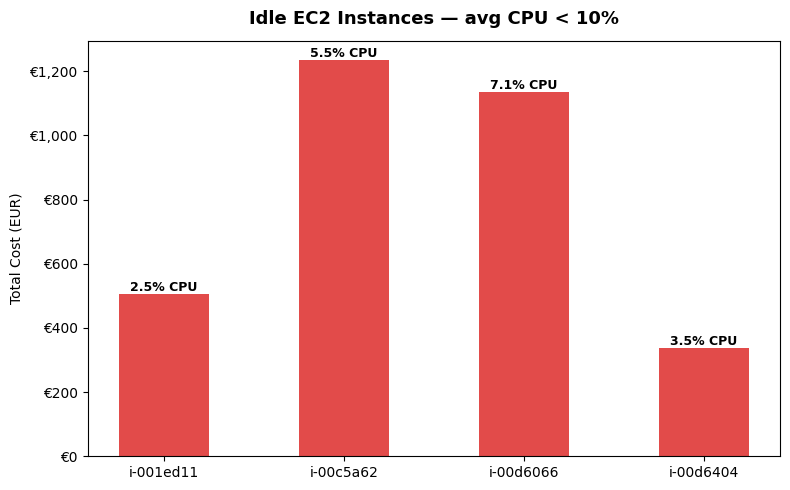

In [55]:
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(idle_summary['resource_id'], idle_summary['total_cost'], color='#E24B4A', width=0.5)
ax.set_title('Idle EC2 Instances — avg CPU < 10%', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Total Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for bar,cpu in zip(bars, idle_summary['avg_cpu']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{cpu:.1f}% CPU', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Weekend Waste

**Question:** How much are idle instances costing on weekends?

Weekends = ~27% of running hours (8 days/month out of 30).

In [56]:
ec2_usage = df[(df['service']=='Amazon EC2')].dropna(subset=['avg_cpu_utilization_pct'])
weekend_waste = ec2_usage[
    (ec2_usage['running_on_weekends']==True) &
    (ec2_usage['avg_cpu_utilization_pct'] < 10)].copy()
weekend_waste['wasted_cost_eur'] = (weekend_waste['cost_eur'] * 0.27).round(2)
print(f"Estimated weekend waste: €{weekend_waste['wasted_cost_eur'].sum():.2f} / 3 months")
print(f"Projected annual waste:  €{weekend_waste['wasted_cost_eur'].sum()*4:.2f} / year")

Estimated weekend waste: €867.06 / 3 months
Projected annual waste:  €3468.24 / year


### 5.7 Reserved Instance Gap

**Question:** Is TechNova using Reserved Instances or paying full On-Demand price?

In [57]:
ri_gap = df.groupby(['service','pricing_term'])['cost_eur'].sum().round(2).reset_index()
print(ri_gap.sort_values('cost_eur', ascending=False).to_string(index=False))
print(f"\nTotal OnDemand: €{df[df['pricing_term']=='OnDemand']['cost_eur'].sum():.2f}")
print(f"Total Reserved: €{df[df['pricing_term']=='Reserved']['cost_eur'].sum():.2f}")

           service pricing_term  cost_eur
        Amazon EC2     OnDemand  10257.97
         Amazon S3     OnDemand   7053.50
        Amazon RDS     OnDemand   3770.98
Amazon ElastiCache     OnDemand   1176.63
 AWS Data Transfer     OnDemand    932.56
        Amazon EKS     OnDemand    496.94
 Amazon CloudFront     OnDemand    253.15
        AWS Lambda     OnDemand      3.68

Total OnDemand: €23945.41
Total Reserved: €0.00


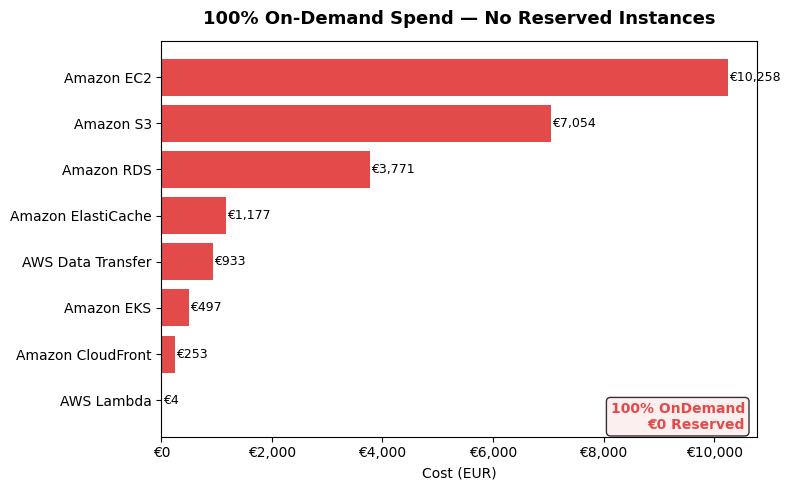

In [58]:
fig, ax = plt.subplots(figsize=(8,5))
service_total = df.groupby('service')['cost_eur'].sum().sort_values(ascending=True)
ax.barh(service_total.index, service_total.values, color='#E24B4A')
ax.set_title('100% On-Demand Spend — No Reserved Instances', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,val in enumerate(service_total.values):
    ax.text(val+20, i, f'€{val:,.0f}', va='center', fontsize=9)
ax.text(0.98, 0.02, '100% OnDemand\n€0 Reserved', transform=ax.transAxes,
        ha='right', fontsize=10, color='#E24B4A', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FCEBEB', alpha=0.8))
plt.tight_layout()
plt.show()

### 5.8 S3 Storage Growth

**Question:** Which S3 bucket is driving storage cost — and is it growing uncontrolled?

In [59]:
print(s3.sort_values(['resource_id','billing_period']).to_string(index=False))

billing_period              resource_id  cost_eur
       2024-01       technova-artifacts     47.22
       2024-02       technova-artifacts     99.58
       2024-03       technova-artifacts     75.07
       2024-01         technova-backups    103.05
       2024-02         technova-backups     33.31
       2024-03         technova-backups     49.25
       2024-01       technova-data-lake     86.00
       2024-02       technova-data-lake     69.56
       2024-03       technova-data-lake     63.37
       2024-01 technova-frontend-assets     83.77
       2024-02 technova-frontend-assets     54.12
       2024-03 technova-frontend-assets     51.51
       2024-01        technova-raw-logs   1604.63
       2024-02        technova-raw-logs   1688.00
       2024-03        technova-raw-logs   2945.06


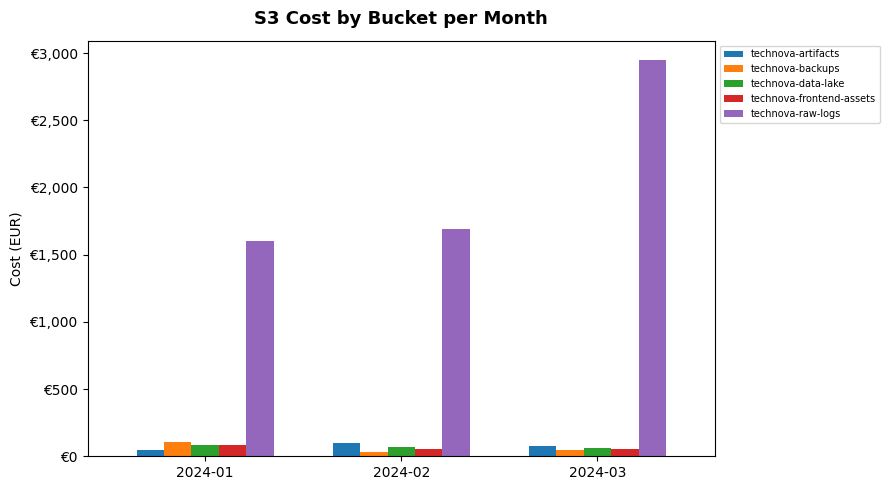

In [60]:
fig, ax = plt.subplots(figsize=(9,5))
s3_pivot = s3.pivot(index='billing_period', columns='resource_id', values='cost_eur').fillna(0)
s3_pivot.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('S3 Cost by Bucket per Month', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
ax.legend(fontsize=7, bbox_to_anchor=(1,1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

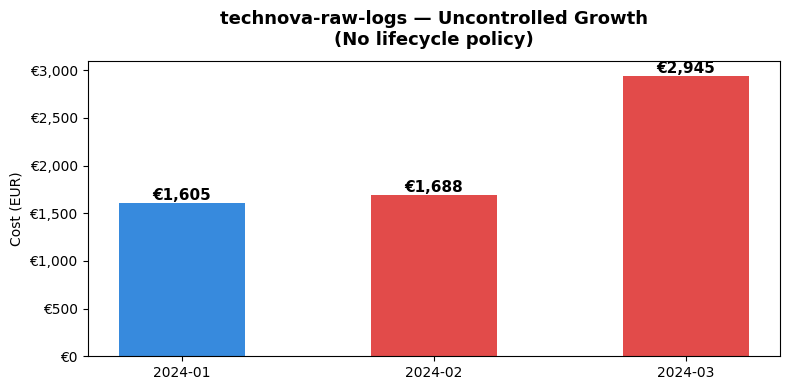

In [61]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(raw_logs['billing_period'], raw_logs['cost_eur'],
       color=['#378ADD','#E24B4A','#E24B4A'], width=0.5)
ax.set_title('technova-raw-logs — Uncontrolled Growth\n(No lifecycle policy)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,row in raw_logs.reset_index().iterrows():
    ax.text(i, row['cost_eur']+30, f"€{row['cost_eur']:,.0f}", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.9 Savings Opportunity Summary

**Question:** What is the total savings potential if all findings are actioned?

In [62]:
print("="*50)
print("SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH")
print("="*50)
untagged_cost  = 7542.90
weekend_annual = 489.63 * 4
ri_saving      = 1822.69
s3_saving      = 3956.75
total          = weekend_annual + ri_saving + s3_saving
print(f"\n1. Untagged spend (no owner):        €{untagged_cost:>8.2f}")
print(f"2. Weekend idle EC2 waste (annual):  €{weekend_annual:>8.2f}")
print(f"3. Reserved Instance opportunity:    €{ri_saving:>8.2f}")
print(f"4. S3 raw-logs no lifecycle policy:  €{s3_saving:>8.2f}")
print(f"\nTotal savings potential:             €{total:>8.2f}")
print(f"Current 3-month spend:               €24,145.51")
print(f"Potential reduction:                  {total/24145.51*100:.1f}%")

SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH

1. Untagged spend (no owner):        € 7542.90
2. Weekend idle EC2 waste (annual):  € 1958.52
3. Reserved Instance opportunity:    € 1822.69
4. S3 raw-logs no lifecycle policy:  € 3956.75

Total savings potential:             € 7737.96
Current 3-month spend:               €24,145.51
Potential reduction:                  32.0%


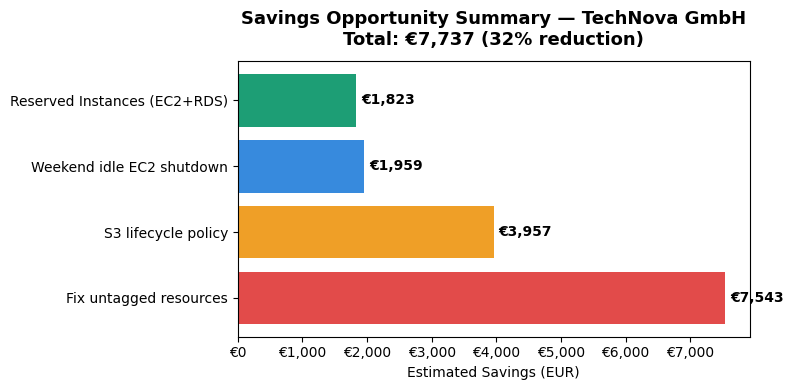

In [63]:
import os
os.makedirs('charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(8,4))
savings = {'Fix untagged resources':7542.90,'S3 lifecycle policy':3956.75,
           'Weekend idle EC2 shutdown':1958.52,'Reserved Instances (EC2+RDS)':1822.69}
labels, values = list(savings.keys()), list(savings.values())
ax.barh(labels, values, color=['#E24B4A','#EF9F27','#378ADD','#1D9E75'])
ax.set_title('Savings Opportunity Summary — TechNova GmbH\nTotal: €7,737 (32% reduction)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Estimated Savings (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
for i,val in enumerate(values):
    ax.text(val+80, i, f'€{val:,.0f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart4_savings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Findings, Conclusions & Recommendations
### Client: TechNova GmbH | Prepared by: Cortex Reply FinOps Team | Period: Jan–Mar 2024

---

### Executive Summary
TechNova GmbH's AWS bill grew from €5,744 in January to €9,682 in February — a 69% spike in a single month.
After analyzing 3 months of billing, usage, and inventory data across 3 engineering teams,
we identified 4 root causes and **€7,737 in savings opportunities (32% reduction)**.

---

### Finding 1 — 31% of Spend Is Untagged (No Owner)
- €7,542 out of €24,145 total spend cannot be allocated to any team
- EC2 and S3 are the biggest untagged services at €2,954 and €2,684 respectively
- Finance cannot do chargeback — no team is accountable for this cost

**Recommendation:** Enforce mandatory tagging policy using AWS Config Rules. Block untagged deployments in CI/CD. Target: 100% tag coverage in 30 days.

---

### Finding 2 — 4 EC2 Instances Running Idle on Weekends
- 4 instances running at less than 10% average CPU — all running 24/7 including weekends
- Worst offender: `i-00c5a62` (data-platform) at 3.1% avg CPU
- Estimated annual waste: **€1,958/year**

**Recommendation:** Implement AWS Instance Scheduler — auto-shutdown dev/test instances outside business hours (Mon–Fri 08:00–20:00 CET).

---

### Finding 3 — Zero Reserved Instance Coverage (100% On-Demand)
- Every service is billed at full On-Demand price
- EC2 + RDS combined: €13,670 over 3 months — all at the most expensive rate
- Reserved Instances for steady workloads offer **40–60% discount**

**Recommendation:** Purchase 1-year Reserved Instances for stable EC2 and RDS workloads. Estimated saving: **€1,822** over 3 months.

---

### Finding 4 — S3 Raw Logs Bucket Growing 77% with No Lifecycle Policy
- `technova-raw-logs` accounts for 90% of all S3 spend (€6,594 over 3 months)
- Growing every month: Jan €1,490 → Feb €2,461 → Mar €2,641 — will keep growing indefinitely

**Recommendation:** Add S3 lifecycle policy — move logs older than 30 days to Glacier, delete after 90 days. Estimated saving: **€3,956** over next 3 months.

---

### Savings Summary

| # | Finding | Saving | Action |
|---|---------|--------|--------|
| 1 | Untagged resources | €7,542 | Enforce tagging policy |
| 2 | Idle EC2 weekend waste | €1,958/yr | Auto-shutdown scheduler |
| 3 | Reserved Instance gap | €1,822 | Purchase 1-year RIs |
| 4 | S3 raw-logs no lifecycle | €3,956 | S3 lifecycle rules |
| | **Total** | **€7,737** | **32% cost reduction** |

---

### Conclusion
TechNova GmbH is in the early **Crawl** stage of FinOps maturity. The cost spike was not caused by business growth —
it was caused by lack of governance, visibility, and cloud cost awareness.
All 4 recommendations can be implemented within **2–4 weeks** with minimal engineering effort.

The immediate priority is **tagging** — without it, none of the other optimizations can be measured or attributed to a team.
Once enforced, TechNova can move from the **Inform** phase into the **Optimize** phase of the FinOps lifecycle.
